In [2]:
# admm_in_involutionnet_full_inn.py
import math
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# -----------------------------
# Data augmentation and normalization for CIFAR-10
# -----------------------------
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=4, pin_memory=True)
test_loader   = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

# -----------------------------
# Involution 2D
# -----------------------------
class Involution2D(nn.Module):
    def __init__(self, channels, kernel_size=3, stride=1, reduction_ratio=4):
        super(Involution2D, self).__init__()
        self.channels = channels
        self.kernel_size = kernel_size
        self.stride = stride

        self.reduce_channels = max(1, channels // reduction_ratio)
        # convs inside Involution (these have weights and will be prunable by ADMM)
        self.conv1 = nn.Conv2d(channels, self.reduce_channels, 1)
        self.bn = nn.BatchNorm2d(self.reduce_channels)
        self.conv2 = nn.Conv2d(self.reduce_channels, kernel_size * kernel_size, 1)
        self.unfold = nn.Unfold(kernel_size=kernel_size, padding=kernel_size // 2, stride=stride)

    def forward(self, x):
        b, c, h, w = x.shape
        weight = self.conv1(x)
        weight = self.bn(weight)
        weight = self.conv2(weight)                                  # [b, k*k, h, w]
        weight = weight.view(b, 1, self.kernel_size * self.kernel_size, h, w)

        x_unfold = self.unfold(x)                                    # [b, c*k*k, h*w]
        x_unfold = x_unfold.view(b, c, self.kernel_size * self.kernel_size, h, w)

        out = (weight * x_unfold).sum(dim=2)                         # [b, c, h, w]
        if self.stride > 1:
            out = out[:, :, ::self.stride, ::self.stride]
        return out

# -----------------------------
# Involutional Neural Network
# -----------------------------
class InvolutionNet(nn.Module):
    def __init__(self):
        super(InvolutionNet, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            Involution2D(64),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            Involution2D(128),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            Involution2D(256),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.fc(x)
        return x

# -----------------------------
# ADMM utils (generalized to any module with .weight)
# -----------------------------
def get_prunable_layers_all_weights(model):
    """
    Return list of (name, module) for modules that have a parameter named 'weight'.
    This will include Conv2d, Linear, and the internal convs inside Involution2D (conv1, conv2).
    """
    prunable = []
    for name, m in model.named_modules():
        if hasattr(m, 'weight') and m.weight is not None:
            prunable.append((name, m))
    return prunable

def make_param_dict(prunable_layers, device):
    """
    Build dicts for W (parameter reference), Z (aux), U (dual) for each prunable layer's .weight.
    Z and U are stored as tensors on the same device.
    """
    W, Z, U = {}, {}, {}
    for name, m in prunable_layers:
        W[name] = m.weight
        Z[name] = m.weight.detach().clone().to(device)
        U[name] = torch.zeros_like(m.weight, device=device)
    return W, Z, U

def project_to_topk(W_tensor, keep_ratio):
    """
    Keep largest-magnitude top-k entries (unstructured). keep_ratio in [0,1].
    """
    if keep_ratio >= 1.0:
        return W_tensor
    if keep_ratio <= 0.0:
        return torch.zeros_like(W_tensor)

    numel = W_tensor.numel()
    k = max(1, int(math.floor(numel * keep_ratio)))
    flat = W_tensor.view(-1)
    abs_flat = flat.abs()
    if k >= numel:
        thresh = 0.0
    else:
        thresh = torch.topk(abs_flat, k, largest=True, sorted=True).values[-1]
    mask = (abs_flat >= thresh).float()
    out = (flat * mask).view_as(W_tensor)
    return out

def admm_z_u_update(W, Z, U, keep_ratios, rho):
    """
    Z-update: projection of (W + U) onto top-k magnitudes (per-tensor keep_ratio).
    U-update: U += W - Z
    """
    with torch.no_grad():
        for name in W.keys():
            keep_ratio = keep_ratios.get(name, 1.0)
            W_plus_U = W[name].detach().to(Z[name].device) + U[name]
            Z[name][:] = project_to_topk(W_plus_U, keep_ratio)
            U[name][:] = U[name] + (W[name].detach().to(U[name].device) - Z[name])

def admm_augmented_loss(ce_loss, W, Z, U, rho):
    """
    L_total = CE + (rho/2) * sum ||W - Z + U||_F^2
    """
    penalty = 0.0
    for name in W.keys():
        penalty = penalty + torch.norm(W[name].to(Z[name].device) - Z[name] + U[name])**2
    return ce_loss + 0.5 * rho * penalty

def apply_hard_prune_from_Z(model, Z):
    """
    Hard set each weight tensor to its Z counterpart (sparse).
    Also produce a mask dict (1 where nonzero) for masked fine-tuning.
    """
    masks = {}
    with torch.no_grad():
        for name, m in model.named_modules():
            if hasattr(m, 'weight') and name in Z:
                z = Z[name].to(m.weight.device)
                m.weight[:] = z
                masks[name] = (z != 0).float()
    return masks

def apply_masks_to_model(model, masks):
    with torch.no_grad():
        for name, m in model.named_modules():
            if hasattr(m, 'weight') and name in masks:
                m.weight[:] = m.weight * masks[name].to(m.weight.device)

# -----------------------------
# Initialize model & ADMM state
# -----------------------------
model = InvolutionNet().to(device)
print(model)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
base_lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=base_lr, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# -----------------------------
# ADMM config (tune these)
# -----------------------------
# PER-LAYER prune ratios (prune %) for targeted modules.
# Use module names as printed by "print(model)" path-like names.
# We'll default to some reasonable values; you can change them.
PRUNE_RATIOS = {
    # convs at beginning of each block
    "block1.0": 0.5,   # Conv2d(3->64)
    "block2.0": 0.6,   # Conv2d(64->128)
    "block3.0": 0.6,   # Conv2d(128->256)
    # internal involution convs (each Involution2D instance has .conv1 and .conv2)
    "block1.3.conv1": 0.5,
    "block1.3.conv2": 0.5,
    "block2.3.conv1": 0.6,
    "block2.3.conv2": 0.6,
    "block3.3.conv1": 0.6,
    "block3.3.conv2": 0.6,
    # fully connected layers
    "fc.1": 0.5,   # Linear(4096->512)
    "fc.3": 0.5,   # Linear(512->10)
}
# convert prune% -> keep_ratio
def build_keep_ratios_for_all(model, prune_ratios):
    keep = {}
    for name, m in model.named_modules():
        if hasattr(m, 'weight') and m.weight is not None:
            pr = prune_ratios.get(name, 0.0)
            keep[name] = max(0.0, min(1.0, 1.0 - pr))
    return keep

KEEP_RATIOS = build_keep_ratios_for_all(model, PRUNE_RATIOS)
rho = 1e-3                       # ADMM penalty (tune)
num_epochs = 30                 # ADMM training epochs
masked_ft_epochs = 10            # fine-tune epochs after hard prune

# Build ADMM containers
prunable = get_prunable_layers_all_weights(model)
W, Z, U = make_param_dict(prunable, device)

# -----------------------------
# Train/Eval helpers
# -----------------------------
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

# -----------------------------
# ADMM training loop
# -----------------------------
best_acc = 0.0
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        ce = criterion(outputs, labels)
        total_loss = admm_augmented_loss(ce, W, Z, U, rho)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

    # Z / U updates once per epoch
    admm_z_u_update(W, Z, U, KEEP_RATIOS, rho)

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        train_acc = evaluate(model, train_loader, device)
        test_acc = evaluate(model, test_loader, device)
        best_acc = max(best_acc, test_acc)
        print(f"[ADMM] Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Best: {best_acc:.2f}%")

# -----------------------------
# Hard prune (project) + masked fine-tuning
# -----------------------------
print("Applying hard projection (pruning) from ADMM Z...")
masks = apply_hard_prune_from_Z(model, Z)

# New optimizer/scheduler for masked fine-tuning
optimizer_ft = optim.Adam(model.parameters(), lr=base_lr * 0.5, weight_decay=5e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=masked_ft_epochs)

print("Starting masked fine-tuning...")
for epoch in range(masked_ft_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        # Enforce mask (keep zeros zero)
        apply_masks_to_model(model, masks)

    scheduler_ft.step()
    if (epoch + 1) % 5 == 0 or epoch == masked_ft_epochs:
        test_acc = evaluate(model, test_loader, device)
        print(f"[Masked-FT] Epoch {epoch+1}/{masked_ft_epochs} | Test Acc: {test_acc:.2f}%")

# -----------------------------
# Final evaluation & sparsity report
# -----------------------------
final_acc = evaluate(model, test_loader, device)
print(f"Final InvolutionNet (ADMM-pruned, full-INN) Accuracy on CIFAR-10: {final_acc:.2f}%")

# Report per-layer sparsity
total_params, total_zeros = 0, 0
with torch.no_grad():
    for name, m in model.named_modules():
        if hasattr(m, 'weight') and m.weight is not None:
            w = m.weight
            zcount = (w == 0).sum().item()
            n = w.numel()
            total_params += n
            total_zeros  += zcount
            if name in KEEP_RATIOS:
                print(f"Layer {name:20s} | keep={KEEP_RATIOS[name]*100:5.1f}% | zeros={zcount}/{n} ({100*zcount/n:5.1f}%)")
print(f"MODEL SPARSITY: {100.0*total_zeros/total_params:.2f}% zeros overall")


Device: cuda
InvolutionNet(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Involution2D(
      (conv1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 9, kernel_size=(1, 1), stride=(1, 1))
      (unfold): Unfold(kernel_size=3, dilation=1, padding=1, stride=1)
    )
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Invo

In [3]:
final_acc = evaluate(model, test_loader, device)
print(f"Final InvolutionNet (ADMM-pruned, full-INN) Accuracy on CIFAR-10: {final_acc:.2f}%")

Final InvolutionNet (ADMM-pruned, full-INN) Accuracy on CIFAR-10: 86.02%



Classification Report:
              precision    recall  f1-score   support

       plane       0.85      0.88      0.87      1000
         car       0.93      0.94      0.93      1000
        bird       0.81      0.80      0.80      1000
         cat       0.75      0.70      0.73      1000
        deer       0.83      0.86      0.85      1000
         dog       0.79      0.80      0.80      1000
        frog       0.87      0.90      0.89      1000
       horse       0.91      0.88      0.89      1000
        ship       0.92      0.91      0.91      1000
       truck       0.91      0.90      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



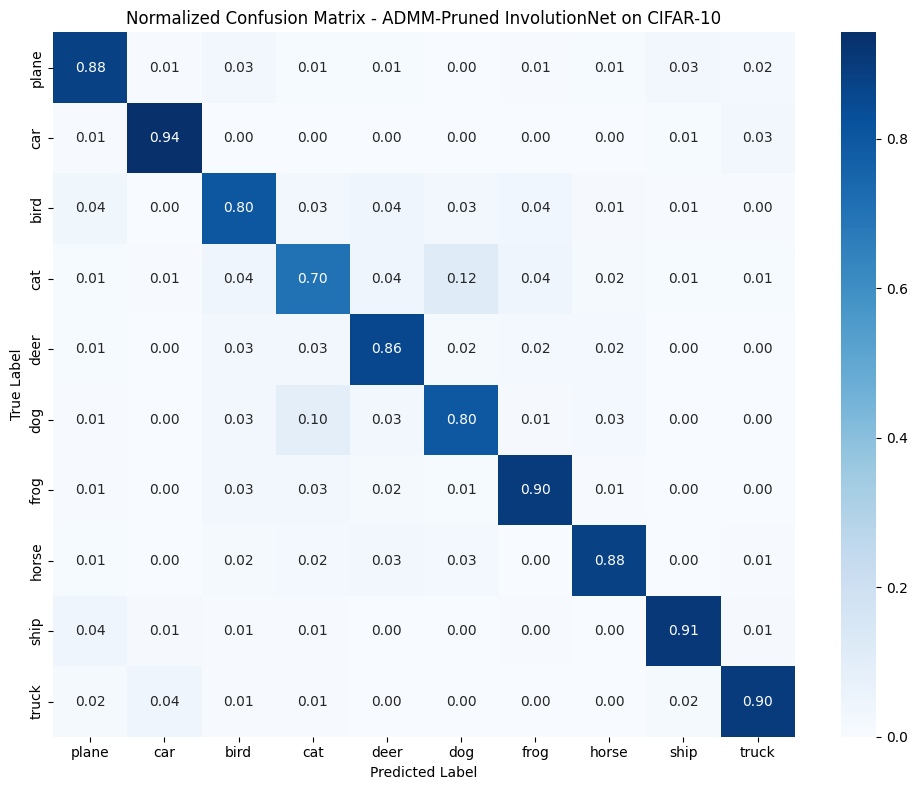

In [4]:
# -----------------------------
# Confusion Matrix Evaluation
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# CIFAR-10 class names
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

@torch.no_grad()
def get_all_preds_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

# Collect predictions and labels
preds, labels = get_all_preds_labels(model, test_loader, device)

# Compute confusion matrix
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Print classification report
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=classes))

# Plot confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Normalized Confusion Matrix - ADMM-Pruned InvolutionNet on CIFAR-10")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [2]:
# admm_in_involutionnet_full_inn.py
import math
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# -----------------------------
# Data augmentation and normalization for CIFAR-10
# -----------------------------
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=4, pin_memory=True)
test_loader   = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

# -----------------------------
# Involution 2D
# -----------------------------
class Involution2D(nn.Module):
    def __init__(self, channels, kernel_size=3, stride=1, reduction_ratio=4):
        super(Involution2D, self).__init__()
        self.channels = channels
        self.kernel_size = kernel_size
        self.stride = stride

        self.reduce_channels = max(1, channels // reduction_ratio)
        # convs inside Involution (these have weights and will be prunable by ADMM)
        self.conv1 = nn.Conv2d(channels, self.reduce_channels, 1)
        self.bn = nn.BatchNorm2d(self.reduce_channels)
        self.conv2 = nn.Conv2d(self.reduce_channels, kernel_size * kernel_size, 1)
        self.unfold = nn.Unfold(kernel_size=kernel_size, padding=kernel_size // 2, stride=stride)

    def forward(self, x):
        b, c, h, w = x.shape
        weight = self.conv1(x)
        weight = self.bn(weight)
        weight = self.conv2(weight)                                  # [b, k*k, h, w]
        weight = weight.view(b, 1, self.kernel_size * self.kernel_size, h, w)

        x_unfold = self.unfold(x)                                    # [b, c*k*k, h*w]
        x_unfold = x_unfold.view(b, c, self.kernel_size * self.kernel_size, h, w)

        out = (weight * x_unfold).sum(dim=2)                         # [b, c, h, w]
        if self.stride > 1:
            out = out[:, :, ::self.stride, ::self.stride]
        return out

# -----------------------------
# Involutional Neural Network
# -----------------------------
class InvolutionNet(nn.Module):
    def __init__(self):
        super(InvolutionNet, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            Involution2D(64),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            Involution2D(128),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            Involution2D(256),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.fc(x)
        return x

# -----------------------------
# ADMM utils (generalized to any module with .weight)
# -----------------------------
def get_prunable_layers_all_weights(model):
    """
    Return list of (name, module) for modules that have a parameter named 'weight'.
    This will include Conv2d, Linear, and the internal convs inside Involution2D (conv1, conv2).
    """
    prunable = []
    for name, m in model.named_modules():
        if hasattr(m, 'weight') and m.weight is not None:
            prunable.append((name, m))
    return prunable

def make_param_dict(prunable_layers, device):
    """
    Build dicts for W (parameter reference), Z (aux), U (dual) for each prunable layer's .weight.
    Z and U are stored as tensors on the same device.
    """
    W, Z, U = {}, {}, {}
    for name, m in prunable_layers:
        W[name] = m.weight
        Z[name] = m.weight.detach().clone().to(device)
        U[name] = torch.zeros_like(m.weight, device=device)
    return W, Z, U

def project_to_topk(W_tensor, keep_ratio):
    """
    Keep largest-magnitude top-k entries (unstructured). keep_ratio in [0,1].
    """
    if keep_ratio >= 1.0:
        return W_tensor
    if keep_ratio <= 0.0:
        return torch.zeros_like(W_tensor)

    numel = W_tensor.numel()
    k = max(1, int(math.floor(numel * keep_ratio)))
    flat = W_tensor.view(-1)
    abs_flat = flat.abs()
    if k >= numel:
        thresh = 0.0
    else:
        thresh = torch.topk(abs_flat, k, largest=True, sorted=True).values[-1]
    mask = (abs_flat >= thresh).float()
    out = (flat * mask).view_as(W_tensor)
    return out

def admm_z_u_update(W, Z, U, keep_ratios, rho):
    """
    Z-update: projection of (W + U) onto top-k magnitudes (per-tensor keep_ratio).
    U-update: U += W - Z
    """
    with torch.no_grad():
        for name in W.keys():
            keep_ratio = keep_ratios.get(name, 1.0)
            W_plus_U = W[name].detach().to(Z[name].device) + U[name]
            Z[name][:] = project_to_topk(W_plus_U, keep_ratio)
            U[name][:] = U[name] + (W[name].detach().to(U[name].device) - Z[name])

def admm_augmented_loss(ce_loss, W, Z, U, rho):
    """
    L_total = CE + (rho/2) * sum ||W - Z + U||_F^2
    """
    penalty = 0.0
    for name in W.keys():
        penalty = penalty + torch.norm(W[name].to(Z[name].device) - Z[name] + U[name])**2
    return ce_loss + 0.5 * rho * penalty

def apply_hard_prune_from_Z(model, Z):
    """
    Hard set each weight tensor to its Z counterpart (sparse).
    Also produce a mask dict (1 where nonzero) for masked fine-tuning.
    """
    masks = {}
    with torch.no_grad():
        for name, m in model.named_modules():
            if hasattr(m, 'weight') and name in Z:
                z = Z[name].to(m.weight.device)
                m.weight[:] = z
                masks[name] = (z != 0).float()
    return masks

def apply_masks_to_model(model, masks):
    with torch.no_grad():
        for name, m in model.named_modules():
            if hasattr(m, 'weight') and name in masks:
                m.weight[:] = m.weight * masks[name].to(m.weight.device)

# -----------------------------
# Initialize model & ADMM state
# -----------------------------
model = InvolutionNet().to(device)
print(model)

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
base_lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=base_lr, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# -----------------------------
# ADMM config (tune these)
# -----------------------------
# PER-LAYER prune ratios (prune %) for targeted modules.
# Use module names as printed by "print(model)" path-like names.
# We'll default to some reasonable values; you can change them.
PRUNE_RATIOS = {
    # convs at beginning of each block
    "block1.0": 0.5,   # Conv2d(3->64)
    "block2.0": 0.6,   # Conv2d(64->128)
    "block3.0": 0.6,   # Conv2d(128->256)
    # internal involution convs (each Involution2D instance has .conv1 and .conv2)
    "block1.3.conv1": 0.5,
    "block1.3.conv2": 0.5,
    "block2.3.conv1": 0.6,
    "block2.3.conv2": 0.6,
    "block3.3.conv1": 0.6,
    "block3.3.conv2": 0.6,
    # fully connected layers
    "fc.1": 0.5,   # Linear(4096->512)
    "fc.3": 0.5,   # Linear(512->10)
}
# convert prune% -> keep_ratio
def build_keep_ratios_for_all(model, prune_ratios):
    keep = {}
    for name, m in model.named_modules():
        if hasattr(m, 'weight') and m.weight is not None:
            pr = prune_ratios.get(name, 0.0)
            keep[name] = max(0.0, min(1.0, 1.0 - pr))
    return keep

KEEP_RATIOS = build_keep_ratios_for_all(model, PRUNE_RATIOS)
rho = 1e-3                       # ADMM penalty (tune)
num_epochs = 100                 # ADMM training epochs
masked_ft_epochs = 20            # fine-tune epochs after hard prune

# Build ADMM containers
prunable = get_prunable_layers_all_weights(model)
W, Z, U = make_param_dict(prunable, device)

# -----------------------------
# Train/Eval helpers
# -----------------------------
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

# -----------------------------
# ADMM training loop
# -----------------------------
best_acc = 0.0
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        ce = criterion(outputs, labels)
        total_loss = admm_augmented_loss(ce, W, Z, U, rho)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

    # Z / U updates once per epoch
    admm_z_u_update(W, Z, U, KEEP_RATIOS, rho)

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        train_acc = evaluate(model, train_loader, device)
        test_acc = evaluate(model, test_loader, device)
        best_acc = max(best_acc, test_acc)
        print(f"[ADMM] Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Best: {best_acc:.2f}%")
'''
# -----------------------------
# Hard prune (project) + masked fine-tuning
# -----------------------------
print("Applying hard projection (pruning) from ADMM Z...")
masks = apply_hard_prune_from_Z(model, Z)

# New optimizer/scheduler for masked fine-tuning
optimizer_ft = optim.Adam(model.parameters(), lr=base_lr * 0.5, weight_decay=5e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=masked_ft_epochs)

print("Starting masked fine-tuning...")
for epoch in range(masked_ft_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        # Enforce mask (keep zeros zero)
        apply_masks_to_model(model, masks)

    scheduler_ft.step()
    if (epoch + 1) % 5 == 0 or epoch == masked_ft_epochs:
        test_acc = evaluate(model, test_loader, device)
        print(f"[Masked-FT] Epoch {epoch+1}/{masked_ft_epochs} | Test Acc: {test_acc:.2f}%")'''

# -----------------------------
# Final evaluation & sparsity report
# -----------------------------
final_acc = evaluate(model, test_loader, device)
print(f"Final InvolutionNet (ADMM-pruned, full-INN) Accuracy on CIFAR-10: {final_acc:.2f}%")

# Report per-layer sparsity
total_params, total_zeros = 0, 0
with torch.no_grad():
    for name, m in model.named_modules():
        if hasattr(m, 'weight') and m.weight is not None:
            w = m.weight
            zcount = (w == 0).sum().item()
            n = w.numel()
            total_params += n
            total_zeros  += zcount
            if name in KEEP_RATIOS:
                print(f"Layer {name:20s} | keep={KEEP_RATIOS[name]*100:5.1f}% | zeros={zcount}/{n} ({100*zcount/n:5.1f}%)")
print(f"MODEL SPARSITY: {100.0*total_zeros/total_params:.2f}% zeros overall")


Device: cuda
InvolutionNet(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Involution2D(
      (conv1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 9, kernel_size=(1, 1), stride=(1, 1))
      (unfold): Unfold(kernel_size=3, dilation=1, padding=1, stride=1)
    )
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Invo